# Bike Availability Modeling



# Part 1 Feature pairs check


Shape after filter: (298946, 25)
Top 20 by |correlation|:
bikes_1d_mean           0.720048
bikes_same_slot_mean    0.596810
capacity                0.205051
lon                     0.124585
humidity                0.011577
day                     0.003829
weekend                 0.003756
temp                    0.002011
minute                 -0.000847
weekday                -0.000935
number                 -0.001356
pressure               -0.002130
hour                   -0.004754
lat                    -0.137569
num_docks_available    -0.717459
stno                         NaN
year                         NaN
month                        NaN
Name: num_bikes_available, dtype: float64


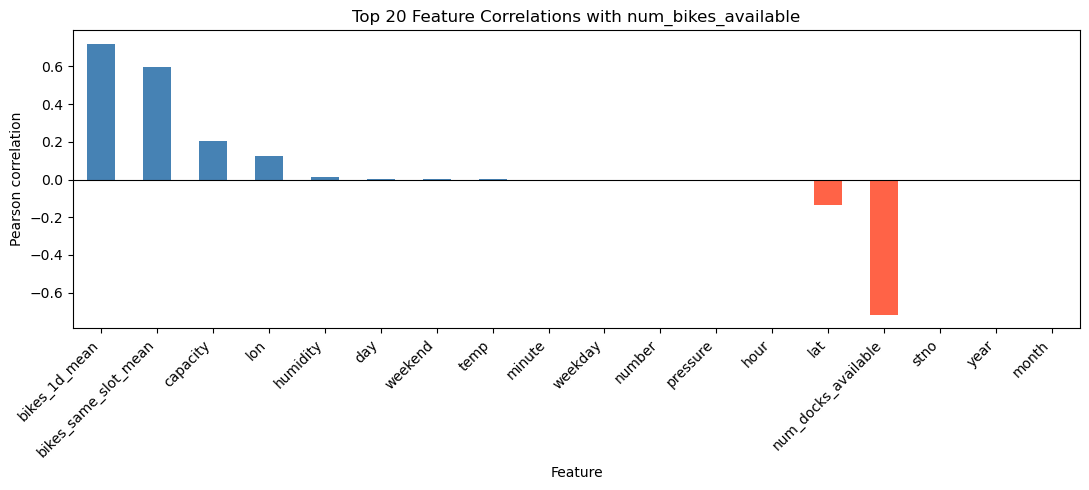

In [2]:
# Part 1: Feature Pair Check
import pandas as pd
import matplotlib.pyplot as plt

INTERVALS_PER_DAY = 144  # 10 minute granularity: 144 records a day

df_raw = pd.read_csv('final_merged_data.csv.gz', compression='gzip')
if 'number' not in df_raw.columns and 'station_id' in df_raw.columns:
    df_raw = df_raw.rename(columns={'station_id': 'number'})

# Weather / time features
df_raw['temp'] = (pd.to_numeric(df_raw['max_air_temperature_celsius']) + pd.to_numeric(df_raw['min_air_temperature_celsius'])) / 2
df_raw['pressure'] = (pd.to_numeric(df_raw['max_barometric_pressure_hpa']) + pd.to_numeric(df_raw['min_barometric_pressure_hpa'])) / 2
hum_avg = (pd.to_numeric(df_raw['max_relative_humidity_percent']) + pd.to_numeric(df_raw['min_relative_humidity_percent'])) / 2
df_raw['humidity'] = (hum_avg > 90).astype(int)
df_raw['weekday'] = pd.to_numeric(df_raw['day']) % 7
df_raw['weekend'] = df_raw['weekday'].isin([5, 6]).astype(int)

# lag features (to prevent data leakage)
df_raw['last_reported'] = pd.to_datetime(df_raw['last_reported'])
df_raw['number'] = pd.to_numeric(df_raw['number'])
df_raw['num_bikes_available'] = pd.to_numeric(df_raw['num_bikes_available'])

lag_base = df_raw.dropna(subset=['last_reported', 'number', 'num_bikes_available']).copy()
lag_base['_orig_idx'] = lag_base.index
lag_base['number'] = lag_base['number'].astype(int)
lag_base = lag_base.sort_values(['number', 'last_reported']).reset_index(drop=True)

g = lag_base.groupby('number')['num_bikes_available']
lag_base['bikes_1d_mean'] = g.transform(
    lambda s: s.shift(1).rolling(INTERVALS_PER_DAY, min_periods=INTERVALS_PER_DAY // 2).mean()
)
# lag feature considering hour/minute: compute historical average for the same time slot
slot_hour = lag_base['last_reported'].dt.hour
slot_minute = lag_base['last_reported'].dt.minute
lag_base['bikes_same_slot_mean'] = (
    lag_base.groupby(['number', slot_hour, slot_minute])['num_bikes_available']
            .transform(lambda s: s.shift(1).expanding(min_periods=3).mean())
)

station_mean = lag_base.groupby('number')['num_bikes_available'].transform('mean')
global_mean = float(lag_base['num_bikes_available'].mean())
for c in ['bikes_1d_mean', 'bikes_same_slot_mean']:
    lag_base[c] = lag_base[c].fillna(station_mean).fillna(global_mean)

df_raw.loc[lag_base['_orig_idx'], 'bikes_1d_mean'] = lag_base['bikes_1d_mean'].values
df_raw.loc[lag_base['_orig_idx'], 'bikes_same_slot_mean'] = lag_base['bikes_same_slot_mean'].values

# Drop redundant raw weather columns
weather_keywords = ['temperature', 'humidity', 'pressure', 'barometric', 'weather', 'wind', 'rain', 'snow', 'soil', 'earth', 'grass', 'quality_indicator']
keep_weather = {'temp', 'pressure', 'humidity'}
drop_cols = [c for c in df_raw.columns if any(k in c.lower() for k in weather_keywords) and c not in keep_weather]
df_model = df_raw.drop(columns=drop_cols, errors='ignore').copy()

# Top 20 correlations
num_cols = df_model.select_dtypes(include=['number']).columns.tolist()
corr = (
    df_model[[c for c in num_cols if c != 'num_bikes_available'] + ['num_bikes_available']]
    .corr(numeric_only=True)['num_bikes_available']
    .drop('num_bikes_available')
)
plot_data = corr.loc[corr.abs().sort_values(ascending=False).head(20).index].sort_values(ascending=False)

print(f'Shape after filter: {df_model.shape}')
print('Top 20 by |correlation|:')
print(plot_data)

plt.figure(figsize=(11, 5))
colors = ['steelblue' if v >= 0 else 'tomato' for v in plot_data.values]
plot_data.plot(kind='bar', color=colors)
plt.title('Top 20 Feature Correlations with num_bikes_available')
plt.xlabel('Feature')
plt.ylabel('Pearson correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Part 1 Conclusion:
 Based on the correlation analysis, the following features should be retained:
- Date/Time features: day, hour, minute,
- Weather features: temp, pressure, humidity
- Geographical features: lon, lat, number
- Bike-related features: bikes_1d_mean, bikes_same_slot_mean, capacity
- Note: num_bikes_available and num_docks_available are complementary variables, thus, num_docks_available is excluded to avoid data leakage and potential overfitting


## Part 2: Data Cleaning
Load raw data, build time/weather/lag features, and produce `df_clean`.


In [3]:
import pandas as pd

# Part 2: Data Cleaning（reuse features from Part 1）
df = df_model.copy()

# Align with training fields
df['available_bikes'] = df['num_bikes_available']
df['lng'] = df['lon']

features = [
    'number', 'capacity', 'day', 'hour', 'minute',
    'temp', 'pressure', 'humidity',
    'lng', 'lat',
    'bikes_1d_mean',
    'bikes_same_slot_mean',
]
target = 'available_bikes'

df_clean = (
    df[features + [target, 'last_reported']]
    .dropna()
    .sort_values('last_reported')
    .reset_index(drop=True)
)
df_clean[features + [target]].to_csv('data_cleaned.csv', index=False)

print(f'Cleaned shape: {df_clean.shape}')
print('Saved: data_cleaned.csv')
display(df_clean.head(3))


Cleaned shape: (298946, 14)
Saved: data_cleaned.csv


,number,capacity,day,hour,minute,temp,pressure,humidity,lng,lat,bikes_1d_mean,bikes_same_slot_mean,available_bikes,last_reported
0,10,16,1,0,10,13.955,1002.41,0,-6.266802,53.344006,12.669023,12.669023,15,2024-12-01 00:10:00
1,53,40,1,0,10,13.955,1002.41,0,-6.260590,53.337130,13.695784,13.695784,7,2024-12-01 00:10:00
2,54,33,1,0,10,13.955,1002.41,0,-6.262980,53.336020,13.502787,13.502787,12,2024-12-01 00:10:00


# Part 3: Model Training
Train linear regression using `df_clean`:
- Use one-hot encoding for `number`
- Use time-ordered 70/30 split

## 3.1. Baseline Model: Linear Regression with Lag Features

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from pathlib import Path

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# keep the list for further models like Random Forest, XGBoost, etc.
models = {
    'Linear Regression': LinearRegression(),
}

results = []

for name, model in models.items():
    print(f"Model training {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4),
    })

results_df = pd.DataFrame(results).set_index('model')
display(results_df)

# Save the model
model_dir = Path('machine_learning') if Path('machine_learning').exists() else Path('.')
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / 'linear_regression_lag_model.joblib'
meta_path = model_dir / 'linear_regression_lag_model_meta.joblib'

joblib.dump(model, model_path)
joblib.dump({'features': features, 'target': target}, meta_path)

print(f'Saved model: {model_path}')
print(f'Saved meta : {meta_path}')


Model training Linear Regression...


,MAE,RMSE,R²
model,,,
Linear Regression,4.9329,6.4873,0.5588


Saved model: linear_regression_lag_model.joblib
Saved meta : linear_regression_lag_model_meta.joblib


# Part 4: Analyse model performance
- 1.Linear Regression
- 2.SVR
- 3.Random Forest 
- 4.Ridge Regression
- 5.Decision Tree

“A standard random train-test split was initially used to establish a baseline model. However, this approach is not ideal for time-series data, as it introduces data leakage by allowing future observations to appear in the training set. Therefore, a time-based split and TimeSeriesSplit cross-validation were later adopted to provide a more realistic evaluation of model performance.”

In [5]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

X = df_clean[features]
y = df_clean[target]

# One-hot encode station id
X = pd.get_dummies(X, columns=['number'], drop_first=True)

# Time-based split (IMPORTANT for time series)
split_idx = int(len(X) * 0.7)

X_train = X.iloc[:split_idx] # past
X_test  = X.iloc[split_idx:] # future

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=10),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ),
    "SVR (Linear)": LinearSVR(max_iter=5000)
}

In [6]:
results = []

tscv = TimeSeriesSplit(n_splits=5)

for name, model in models.items():
    print(f"\nTraining {name}...")

    # ---- Scale ONLY for SVR ----
    if "SVR" in name:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        cv_mae = -cross_val_score(model, X_train_scaled, y_train, cv=tscv,
                                  scoring='neg_mean_absolute_error').mean()
        cv_r2 = cross_val_score(model, X_train_scaled, y_train, cv=tscv,
                                scoring='r2').mean()
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        cv_mae = -cross_val_score(model, X_train, y_train, cv=tscv,
                                  scoring='neg_mean_absolute_error').mean()
        cv_r2 = cross_val_score(model, X_train, y_train, cv=tscv,
                                scoring='r2').mean()

    # ---- Test metrics ----
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "CV MAE": round(cv_mae, 4),
        "CV R²": round(cv_r2, 4),
        "Test MAE": round(mae, 4),
        "Test RMSE": round(rmse, 4),
        "Test R²": round(r2, 4)
    })

results_df = pd.DataFrame(results).sort_values(by="Test R²", ascending=False)
display(results_df)


Training Linear Regression...

Training Ridge Regression...

Training Decision Tree...

Training Random Forest...

Training SVR (Linear)...


KeyboardInterrupt: 

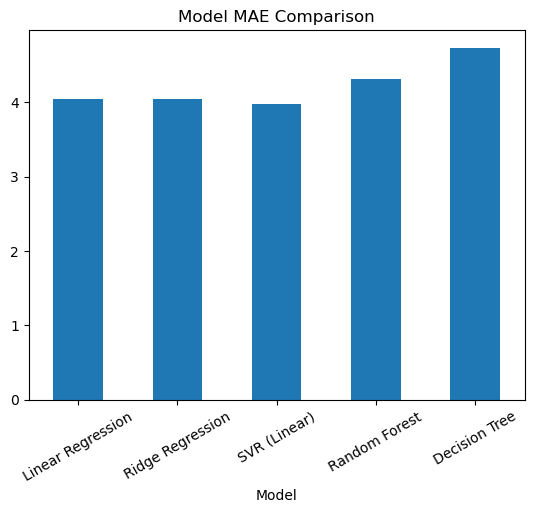

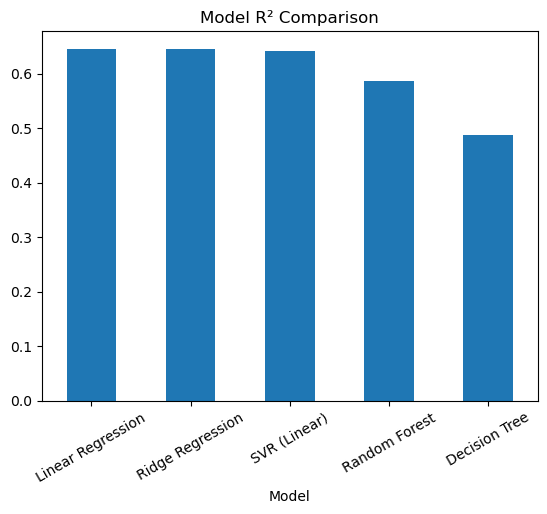

In [ ]:
import matplotlib.pyplot as plt

# MAE comparison
results_df.set_index('Model')['Test MAE'].plot(kind='bar', title='Model MAE Comparison')
plt.xticks(rotation=30)
plt.show()

# R² comparison
results_df.set_index('Model')['Test R²'].plot(kind='bar', title='Model R² Comparison')
plt.xticks(rotation=30)
plt.show()

## Model Comparison and Analysis

### Overall Performance

Among the evaluated models, **Support Vector Regression (SVR)** achieved the lowest test Mean Absolute Error (MAE ≈ 3.98), indicating the best predictive accuracy in terms of absolute error. Linear Regression and Ridge Regression performed very similarly, both achieving MAE values around 4.05 and R² scores of approximately 0.645. Random Forest and Decision Tree performed worse, with higher MAE and lower R² values.

### Linear vs Ridge Regression

Linear Regression and Ridge Regression produced nearly identical results. This suggests that **regularisation had minimal impact**, likely because the feature set is relatively small and does not suffer heavily from multicollinearity. Therefore, the relationship between features and target appears sufficiently stable for a standard linear model.

### SVR Performance

SVR (Linear) slightly outperformed both linear models in terms of MAE, suggesting it captures subtle patterns not fully modelled by ordinary least squares. However, its R² score is slightly lower than Linear Regression, indicating that while it reduces absolute error, it may not explain overall variance as effectively.

### Tree-Based Models

Random Forest and Decision Tree performed noticeably worse than the other models. This is somewhat unexpected, as tree-based models typically excel at capturing non-linear relationships. However, in this case, the relatively simple feature set may limit their ability to leverage their full potential. The Decision Tree in particular shows signs of **overfitting**, with the lowest cross-validation R² (≈ 0.32), indicating poor generalisation.

### Cross-Validation Insights

Cross-validation results show that Linear and Ridge Regression are the most stable models, with consistent CV MAE (~5.62) and CV R² (~0.47). In contrast, the Decision Tree exhibits the largest gap between training and validation performance, reinforcing concerns about overfitting.

### Key Takeaways

* **Best MAE (accuracy):** SVR
* **Best R² (explained variance):** Linear Regression / Ridge Regression
* **Most stable models:** Linear Regression and Ridge Regression
* **Worst performer:** Decision Tree

### Conclusion

Overall, linear models performed strongly and consistently, suggesting that the relationship between features and bike availability is largely linear under the current feature set. While SVR achieved the lowest prediction error, its increased complexity may not justify its use over simpler linear models. Tree-based models underperformed, likely due to the absence of richer temporal features such as lag variables. With this in mind, Linear Regression is the strongest choice of model.


# Part 5 :Prediction applied on Flask API
### modification on APP.py to load the model and make prediction